# 04 V2 实验报告

**用途**：汇总 V2 的稳健性、效率、错误类型和扩展任务结果，作为第二版分析报告。  
**定位**：这不是 V1 结论的覆盖版，而是独立的 V2 报告壳。

---

## 摘要

本报告当前优先回答五个 V2 问题：
1. 将重复数从 3 提高到 10 后，16K / 32K 的结果是否更稳定
2. `style_aligned` / `numeric_confusable` / `multi_key` 三类 needle 的难度排序是什么
3. 哪个模型在“准确率 - 输出 token - 单位成本”三维上更均衡
4. `multi_hop` 与跨领域扩展是否已经接入并形成可分析结果
5. badcase taxonomy 能否把“统计结果”推进成“可指导优化”的评测资产

当前已经出现四个值得前置到结论区的强信号：
- `numeric_confusable` 是平均最难的变体，说明近似数字 / 字符串干扰比 style 对齐或多 key 干扰更容易击穿检索稳定性。
- DeepSeek-V3 (API: `deepseek-chat`) 的最大问题不是“找不到”，而是“输出冗余但包含正确答案”；这类 EM-only miss 已经成为当前最常见 badcase。
- Kimi (Moonshot, API: `moonshot-v1-128k`) 在 32K 条件下 Contains = 0.0%，Wilson 95% CI 上界仅 5.2%，更接近稳定失效而不是一次偶然波动。
- `multi_hop` 已正式进入统一报告，但当前仍只是 4 条人工设计的真实业务口径样本 / 模型，三家 Contains 都在 50.0%，区间仍宽，应视为 real-task pilot 而非稳定排名。

本文后续统一使用“展示名（API 名）”格式：DeepSeek-V3 (API: `deepseek-chat`)、Kimi (Moonshot, API: `moonshot-v1-128k`)、Qwen-Long (API: `qwen-long`)。

In [1]:
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'v2' and PROJECT_ROOT.parent.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display as ipy_display

import src.metrics_v2 as metrics_v2_module

importlib.reload(metrics_v2_module)

from src.metrics_v2 import (
    attach_badcase_taxonomy,
    summarize_badcase_taxonomy,
    summarize_v2,
    summarize_variant_matrix,
)

MODEL_DISPLAY_NAMES = {
    'deepseek': 'DeepSeek-V3 (API: deepseek-chat)',
    'kimi': 'Kimi (Moonshot, API: moonshot-v1-128k)',
    'qwen': 'Qwen-Long (API: qwen-long)',
}

BADCASE_DISPLAY_ORDER = [
    '找到了附近信息但抽错目标值',
    '被相似数字干扰',
    '深层位置召回失败',
    '输出冗余但包含正确答案',
    '多 key 条件下定位失败',
    '未作答或信息未命中',
]


def format_model_name(model_key):
    if pd.isna(model_key):
        return model_key
    return MODEL_DISPLAY_NAMES.get(str(model_key), str(model_key))



def with_model_labels(frame, column='model'):
    if frame.empty or column not in frame.columns:
        return frame.copy()
    labeled = frame.copy()
    labeled[column] = labeled[column].apply(format_model_name)
    return labeled


matplotlib.rcParams['font.sans-serif'] = ['PingFang SC', 'Hiragino Sans GB', 'Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

processed_dir = PROJECT_ROOT / 'results/v2/processed'
scored_path = processed_dir / 'scored_results.csv'
dataset_path = PROJECT_ROOT / 'data/processed/v2/niah_dataset.jsonl'
multihop_dataset_path = PROJECT_ROOT / 'data/processed/v2/multihop_dataset.jsonl'
figures_dir = PROJECT_ROOT / 'results/v2/figures'

if scored_path.exists():
    df = pd.read_csv(scored_path)
    if 'task' not in df.columns:
        df['task'] = 'niah'
    df['task'] = df['task'].fillna('niah')
    df = attach_badcase_taxonomy(df)

    dataset_df = pd.read_json(dataset_path, lines=True) if dataset_path.exists() else pd.DataFrame()
    multihop_dataset_df = pd.read_json(multihop_dataset_path, lines=True) if multihop_dataset_path.exists() else pd.DataFrame()

    niah_df = df[df['task'] == 'niah'].copy()
    multihop_df = df[df['task'] == 'multi_hop'].copy()
    models = sorted(df['model'].dropna().unique().tolist())
    model_labels = [format_model_name(model) for model in models]
    variants = sorted(niah_df['variant'].dropna().unique().tolist()) if 'variant' in niah_df.columns else []
    domains = sorted(niah_df['domain'].dropna().unique().tolist()) if 'domain' in niah_df.columns else []

    expected_niah_per_model = len(dataset_df)
    expected_niah_total = expected_niah_per_model * len(models) if expected_niah_per_model else len(niah_df)
    actual_niah_total = len(niah_df)
    missing_niah_total = expected_niah_total - actual_niah_total
    coverage_pct = actual_niah_total / expected_niah_total * 100 if expected_niah_total else 0.0

    expected_multihop_per_model = len(multihop_dataset_df)
    expected_multihop_total = expected_multihop_per_model * len(models) if expected_multihop_per_model else len(multihop_df)
    actual_multihop_total = len(multihop_df)
    multihop_coverage_pct = actual_multihop_total / expected_multihop_total * 100 if expected_multihop_total else 0.0

    coverage_by_length = (
        niah_df.groupby(['model', 'context_length']).size().unstack(fill_value=0)
        if not niah_df.empty else pd.DataFrame()
        )
    repeat_estimate = (
        int(dataset_df.groupby(['context_length', 'depth_pct']).size().median())
        if not dataset_df.empty else None
        )

    model_summary = summarize_v2(niah_df) if not niah_df.empty else pd.DataFrame()
    variant_summary = summarize_variant_matrix(niah_df) if not niah_df.empty else pd.DataFrame()
    length_summary = summarize_v2(niah_df, group_cols=['model', 'context_length']) if not niah_df.empty else pd.DataFrame()
    task_summary = summarize_v2(df, group_cols=['model', 'task']) if not df.empty else pd.DataFrame()
    multihop_summary = summarize_v2(multihop_df) if not multihop_df.empty else pd.DataFrame()
    multihop_domain_summary = summarize_v2(multihop_df, group_cols=['model', 'domain']) if not multihop_df.empty else pd.DataFrame()

    niah_badcases = df[(df['task'] == 'niah') & (df['is_badcase'] == 1)].copy()
    niah_badcase_summary = summarize_badcase_taxonomy(niah_df)
    niah_badcase_summary_overall = summarize_badcase_taxonomy(niah_df, group_cols=['badcase_taxonomy'])
    multihop_badcase_summary = summarize_badcase_taxonomy(multihop_df) if not multihop_df.empty else pd.DataFrame()

    if not niah_badcase_summary.empty:
        niah_badcase_summary['badcase_taxonomy'] = pd.Categorical(
            niah_badcase_summary['badcase_taxonomy'],
            categories=BADCASE_DISPLAY_ORDER,
            ordered=True,
        )
        niah_badcase_summary = niah_badcase_summary.sort_values(['model', 'badcase_taxonomy', 'n'], ascending=[True, True, False])
    if not niah_badcase_summary_overall.empty:
        niah_badcase_summary_overall['badcase_taxonomy'] = pd.Categorical(
            niah_badcase_summary_overall['badcase_taxonomy'],
            categories=BADCASE_DISPLAY_ORDER,
            ordered=True,
        )
        niah_badcase_summary_overall = niah_badcase_summary_overall.sort_values(['badcase_taxonomy', 'n'], ascending=[True, False])

    taxonomy_example_cols = [
        'model', 'variant', 'domain', 'context_length', 'depth_pct',
        'question', 'expected_answer', 'model_response', 'badcase_taxonomy',
        'contains_score', 'em_score',
    ]
    representative_badcases = (
        niah_badcases.sort_values(['badcase_taxonomy', 'model', 'context_length', 'depth_pct'])
        .groupby('badcase_taxonomy', dropna=False)
        .head(3)[taxonomy_example_cols]
        if not niah_badcases.empty else pd.DataFrame(columns=taxonomy_example_cols)
    )
    em_gap_examples = (
        niah_badcases[niah_badcases['badcase_taxonomy'] == '输出冗余但包含正确答案']
        .sort_values(['model', 'context_length', 'depth_pct'])
        [taxonomy_example_cols]
        .head(12)
        if not niah_badcases.empty else pd.DataFrame(columns=taxonomy_example_cols)
    )
    real_task_pilot_df = (
        multihop_dataset_df[
            ['sample_id', 'domain', 'difficulty', 'hops', 'context_length', 'question', 'answer']
        ].rename(columns={'answer': 'expected_answer'})
        if not multihop_dataset_df.empty else pd.DataFrame()
    )

    if not task_summary.empty:
        task_summary.to_csv(processed_dir / 'summary_by_model_task.csv', index=False, encoding='utf-8-sig')
    if not niah_badcase_summary.empty:
        niah_badcase_summary.to_csv(processed_dir / 'summary_by_model_badcase_taxonomy.csv', index=False, encoding='utf-8-sig')
    if not niah_badcase_summary_overall.empty:
        niah_badcase_summary_overall.to_csv(processed_dir / 'summary_by_badcase_taxonomy.csv', index=False, encoding='utf-8-sig')
    if not representative_badcases.empty:
        representative_badcases.to_csv(processed_dir / 'badcase_examples.csv', index=False, encoding='utf-8-sig')

    print(f'✅ 加载 V2 评分结果: {len(df)} 条，PROJECT_ROOT={PROJECT_ROOT}')
    print(f'   模型: {model_labels}')
    print(f'   NIAH 覆盖率: {coverage_pct:.1f}% ({actual_niah_total}/{expected_niah_total})')
    if repeat_estimate is not None:
        print(f'   估计重复数: {repeat_estimate}')
    if not multihop_df.empty:
        print(f'   multi_hop 结果: {actual_multihop_total}/{expected_multihop_total} ({multihop_coverage_pct:.1f}%)')
    elif not multihop_dataset_df.empty:
        print(f'   multi_hop 数据集已准备: {len(multihop_dataset_df)} 条，当前尚未评测')
else:
    print('⚠️ 请先运行 notebooks/v2/03_analysis_visualization_v2.ipynb 生成 V2 评分结果和图表')

✅ 加载 V2 评分结果: 1062 条，PROJECT_ROOT=/Users/melody/Desktop/Eval
   模型: ['DeepSeek-V3 (API: deepseek-chat)', 'Kimi (Moonshot, API: moonshot-v1-128k)', 'Qwen-Long (API: qwen-long)']
   NIAH 覆盖率: 100.0% (1050/1050)
   估计重复数: 10
   multi_hop 结果: 12/12 (100.0%)


## 1. 实验设置

In [2]:
if scored_path.exists():
    print('实验规模：')
    print(f'  已完成 NIAH 样本数:  {actual_niah_total}')
    print(f'  期望 NIAH 样本数:    {expected_niah_total}')
    print(f'  NIAH 覆盖率:         {coverage_pct:.1f}%')
    print(f'  已完成 multi_hop:    {actual_multihop_total}')
    print(f'  期望 multi_hop:      {expected_multihop_total}')
    print(f'  multi_hop 覆盖率:    {multihop_coverage_pct:.1f}%')
    print(f'  评测模型:            {model_labels}')
    print(f'  变体:                {variants}')
    print(f'  领域:                {domains}')
    print(f'  上下文长度:          {sorted(niah_df["context_length"].dropna().unique().tolist()) if not niah_df.empty else []} chars')
    print(f'  Needle 深度点:       {sorted(niah_df["depth_pct"].dropna().unique().tolist()) if not niah_df.empty else []}%')
    print(f'  task:                {sorted(df["task"].dropna().unique().tolist())}')
    if repeat_estimate is not None:
        print(f'  估计重复数:          {repeat_estimate}')
    if not coverage_by_length.empty:
        coverage_by_length_display = coverage_by_length.rename(index=format_model_name)
        print('\n当前覆盖数（model x context_length）：')
        print(coverage_by_length_display.to_string())
    if missing_niah_total > 0:
        print(f'\n⚠️ 当前仍缺少 {missing_niah_total} 条 NIAH 结果，报告只能作为趋势版。')

实验规模：
  已完成 NIAH 样本数:  1050
  期望 NIAH 样本数:    1050
  NIAH 覆盖率:         100.0%
  已完成 multi_hop:    12
  期望 multi_hop:      12
  multi_hop 覆盖率:    100.0%
  评测模型:            ['DeepSeek-V3 (API: deepseek-chat)', 'Kimi (Moonshot, API: moonshot-v1-128k)', 'Qwen-Long (API: qwen-long)']
  变体:                ['multi_key', 'numeric_confusable', 'style_aligned']
  领域:                ['finance', 'healthcare', 'logistics', 'manufacturing', 'retail']
  上下文长度:          [2000, 4000, 8000, 16000, 32000] chars
  Needle 深度点:       [0.0, 10.0, 25.0, 50.0, 75.0, 90.0, 100.0]%
  task:                ['multi_hop', 'niah']
  估计重复数:          10

当前覆盖数（model x context_length）：
context_length                          2000   4000   8000   16000  32000
model                                                                    
DeepSeek-V3 (API: deepseek-chat)           70     70     70     70     70
Kimi (Moonshot, API: moonshot-v1-128k)     70     70     70     70     70
Qwen-Long (API: qwen-long)                 7

## 2. 结果概览

In [3]:
if scored_path.exists() and not model_summary.empty:
    display_cols = [
        'model', 'n', 'em_pct', 'contains_pct',
        'contains_ci_low_pct', 'contains_ci_high_pct',
        'avg_latency_s', 'avg_response_chars', 'avg_completion_tokens',
        'cost_per_contains_hit_cny', 'contains_per_1k_output_tokens',
        ]
    print('模型级摘要：')
    model_summary_display = with_model_labels(
        model_summary[display_cols].sort_values('contains_pct', ascending=False)
    )
    display(model_summary_display)

    best_contains = model_summary.sort_values(['contains_pct', 'contains_ci_low_pct'], ascending=False).iloc[0]
    cheapest = model_summary.sort_values('cost_per_contains_hit_cny', ascending=True).iloc[0]
    shortest = model_summary.sort_values('avg_completion_tokens', ascending=True).iloc[0]

    print('\n快速结论：')
    print(f'  准确率最强: {format_model_name(best_contains["model"])}，Contains={best_contains["contains_pct"]:.1f}%')
    print(f'  单位命中成本最低: {format_model_name(cheapest["model"])}，{cheapest["cost_per_contains_hit_cny"]:.4f} CNY / hit')
    print(f'  输出最短: {format_model_name(shortest["model"])}，平均 completion={shortest["avg_completion_tokens"]:.1f} tokens')

模型级摘要：


,model,n,em_pct,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_latency_s,avg_response_chars,avg_completion_tokens,cost_per_contains_hit_cny,contains_per_1k_output_tokens
0,DeepSeek-V3 (API: deepseek-chat),350,61.1,90.6,87.1,93.2,0.73,6.1,4.8,0.0057,213.38
2,Qwen-Long (API: qwen-long),350,80.0,81.4,77.0,85.2,7.14,6.0,5.5,0.0397,164.01
1,"Kimi (Moonshot, API: moonshot-v1-128k)",350,58.9,63.1,58.0,68.0,1.06,4.5,4.5,0.3919,103.73



快速结论：
  准确率最强: DeepSeek-V3 (API: deepseek-chat)，Contains=90.6%
  单位命中成本最低: DeepSeek-V3 (API: deepseek-chat)，0.0057 CNY / hit
  输出最短: Kimi (Moonshot, API: moonshot-v1-128k)，平均 completion=4.5 tokens


## 3. 变体难度与稳定性

In [4]:
if scored_path.exists() and not variant_summary.empty:
    print('模型 x 变体摘要：')
    variant_summary_display = with_model_labels(
        variant_summary[
            [
                'model', 'variant', 'n', 'contains_pct',
                'contains_ci_low_pct', 'contains_ci_high_pct',
                'avg_completion_tokens', 'cost_per_contains_hit_cny',
            ]
        ].sort_values(['variant', 'contains_pct'], ascending=[True, False])
    )
    display(variant_summary_display)

    variant_pivot = (
        variant_summary.assign(model=variant_summary['model'].apply(format_model_name))
        .pivot(index='model', columns='variant', values='contains_pct')
        .round(1)
    )
    print('变体准确率矩阵 (%)：')
    display(variant_pivot)

    stability_focus = length_summary[length_summary['context_length'].isin([16000, 32000])].copy()
    if not stability_focus.empty:
        print('16K / 32K 稳定性观察：')
        stability_focus_display = with_model_labels(
            stability_focus[
                [
                    'model', 'context_length', 'n', 'contains_pct',
                    'contains_ci_low_pct', 'contains_ci_high_pct',
                    'avg_completion_tokens', 'cost_per_contains_hit_cny',
                ]
            ].sort_values(['context_length', 'contains_pct'], ascending=[True, False])
        )
        display(stability_focus_display)

    if not task_summary.empty and 'multi_hop' in task_summary['task'].values:
        print('扩展任务摘要：')
        display(with_model_labels(task_summary[task_summary['task'] == 'multi_hop']))

模型 x 变体摘要：


,model,variant,n,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_completion_tokens,cost_per_contains_hit_cny
0,DeepSeek-V3 (API: deepseek-chat),multi_key,120,91.7,85.3,95.4,4.3,0.0064
6,Qwen-Long (API: qwen-long),multi_key,120,91.7,85.3,95.4,6.8,0.0372
3,"Kimi (Moonshot, API: moonshot-v1-128k)",multi_key,120,65.8,57.0,73.7,4.7,0.3620
1,DeepSeek-V3 (API: deepseek-chat),numeric_confusable,114,86.0,78.4,91.2,5.9,0.0057
7,Qwen-Long (API: qwen-long),numeric_confusable,114,62.3,53.1,70.6,5.1,0.0516
4,"Kimi (Moonshot, API: moonshot-v1-128k)",numeric_confusable,114,53.5,44.4,62.4,4.8,0.4871
2,DeepSeek-V3 (API: deepseek-chat),style_aligned,116,94.0,88.1,97.0,4.1,0.0051
8,Qwen-Long (API: qwen-long),style_aligned,116,89.7,82.8,94.0,4.6,0.0342
5,"Kimi (Moonshot, API: moonshot-v1-128k)",style_aligned,116,69.8,60.9,77.4,4.0,0.3495


变体准确率矩阵 (%)：


variant,multi_key,numeric_confusable,style_aligned
model,,,
DeepSeek-V3 (API: deepseek-chat),91.7,86.0,94.0
"Kimi (Moonshot, API: moonshot-v1-128k)",65.8,53.5,69.8
Qwen-Long (API: qwen-long),91.7,62.3,89.7


16K / 32K 稳定性观察：


,model,context_length,n,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_completion_tokens,cost_per_contains_hit_cny
3,DeepSeek-V3 (API: deepseek-chat),16000,70,85.7,75.7,92.1,4.4,0.0078
13,Qwen-Long (API: qwen-long),16000,70,82.9,72.4,89.9,5.4,0.0521
8,"Kimi (Moonshot, API: moonshot-v1-128k)",16000,70,74.3,63.0,83.1,5.0,0.8608
4,DeepSeek-V3 (API: deepseek-chat),32000,70,98.6,92.3,99.7,4.9,0.0135
14,Qwen-Long (API: qwen-long),32000,70,82.9,72.4,89.9,5.6,0.0973
9,"Kimi (Moonshot, API: moonshot-v1-128k)",32000,70,0.0,0.0,5.2,0.0,0.0000


扩展任务摘要：


,model,task,n,em_pct,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_latency_s,avg_response_chars,avg_completion_tokens,total_cost_cny,cost_per_contains_hit_cny,cost_per_em_hit_cny,contains_per_1k_output_tokens
0,DeepSeek-V3 (API: deepseek-chat),multi_hop,4,50.0,50.0,15.0,85.0,0.66,5.2,3.2,0.0005,0.0002,0.0002,145.83
2,"Kimi (Moonshot, API: moonshot-v1-128k)",multi_hop,4,25.0,50.0,15.0,85.0,0.64,8.5,7.2,0.0312,0.0156,0.0312,62.50
4,Qwen-Long (API: qwen-long),multi_hop,4,50.0,50.0,15.0,85.0,0.51,5.0,4.8,0.0020,0.0010,0.0010,100.00


## 4. 图表回顾

### DeepSeek-V3 (API: deepseek-chat)


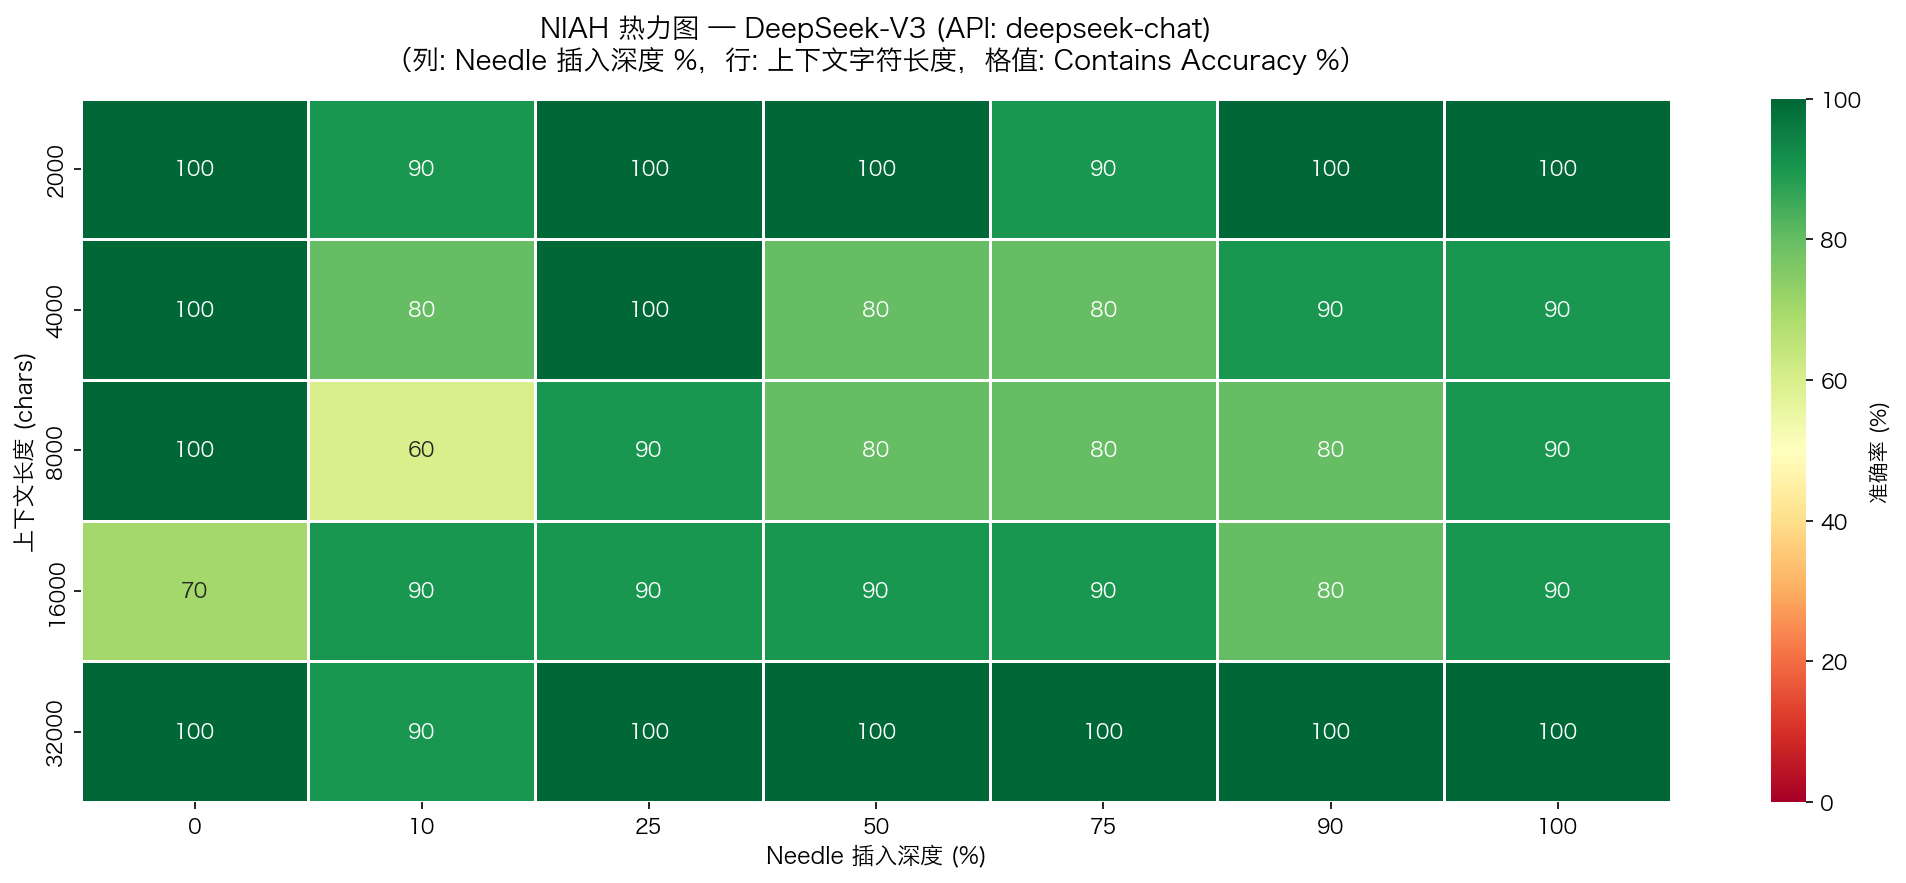

### Kimi (Moonshot, API: moonshot-v1-128k)


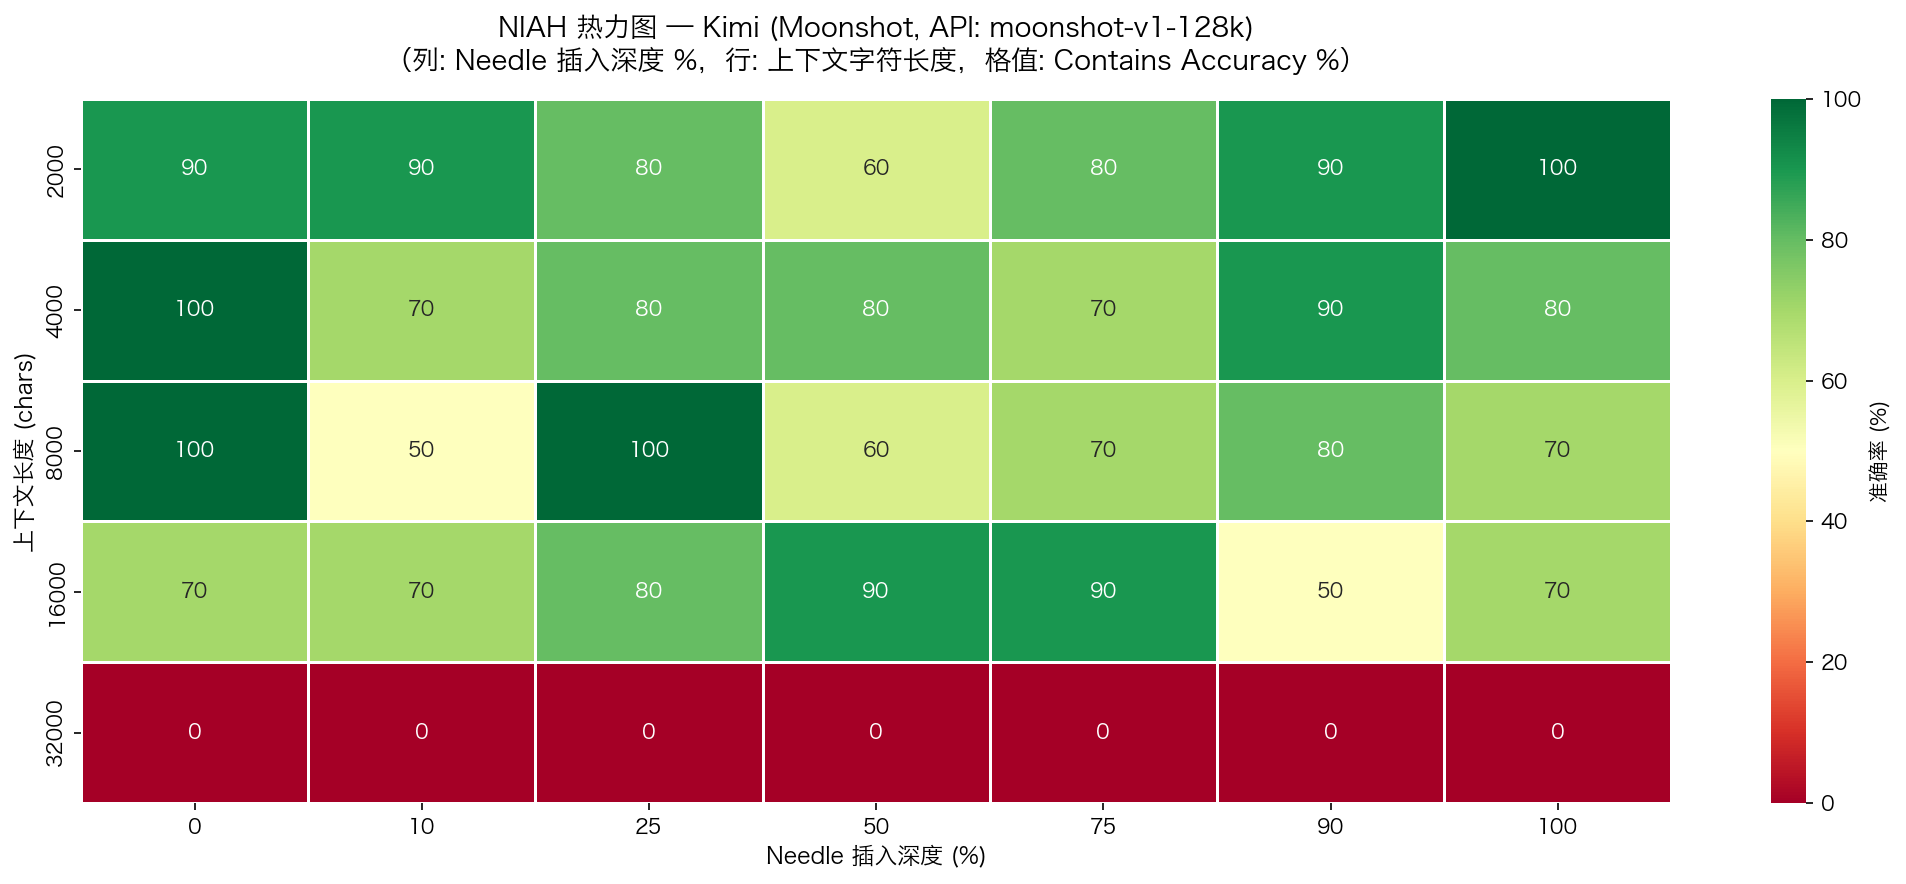

### Qwen-Long (API: qwen-long)


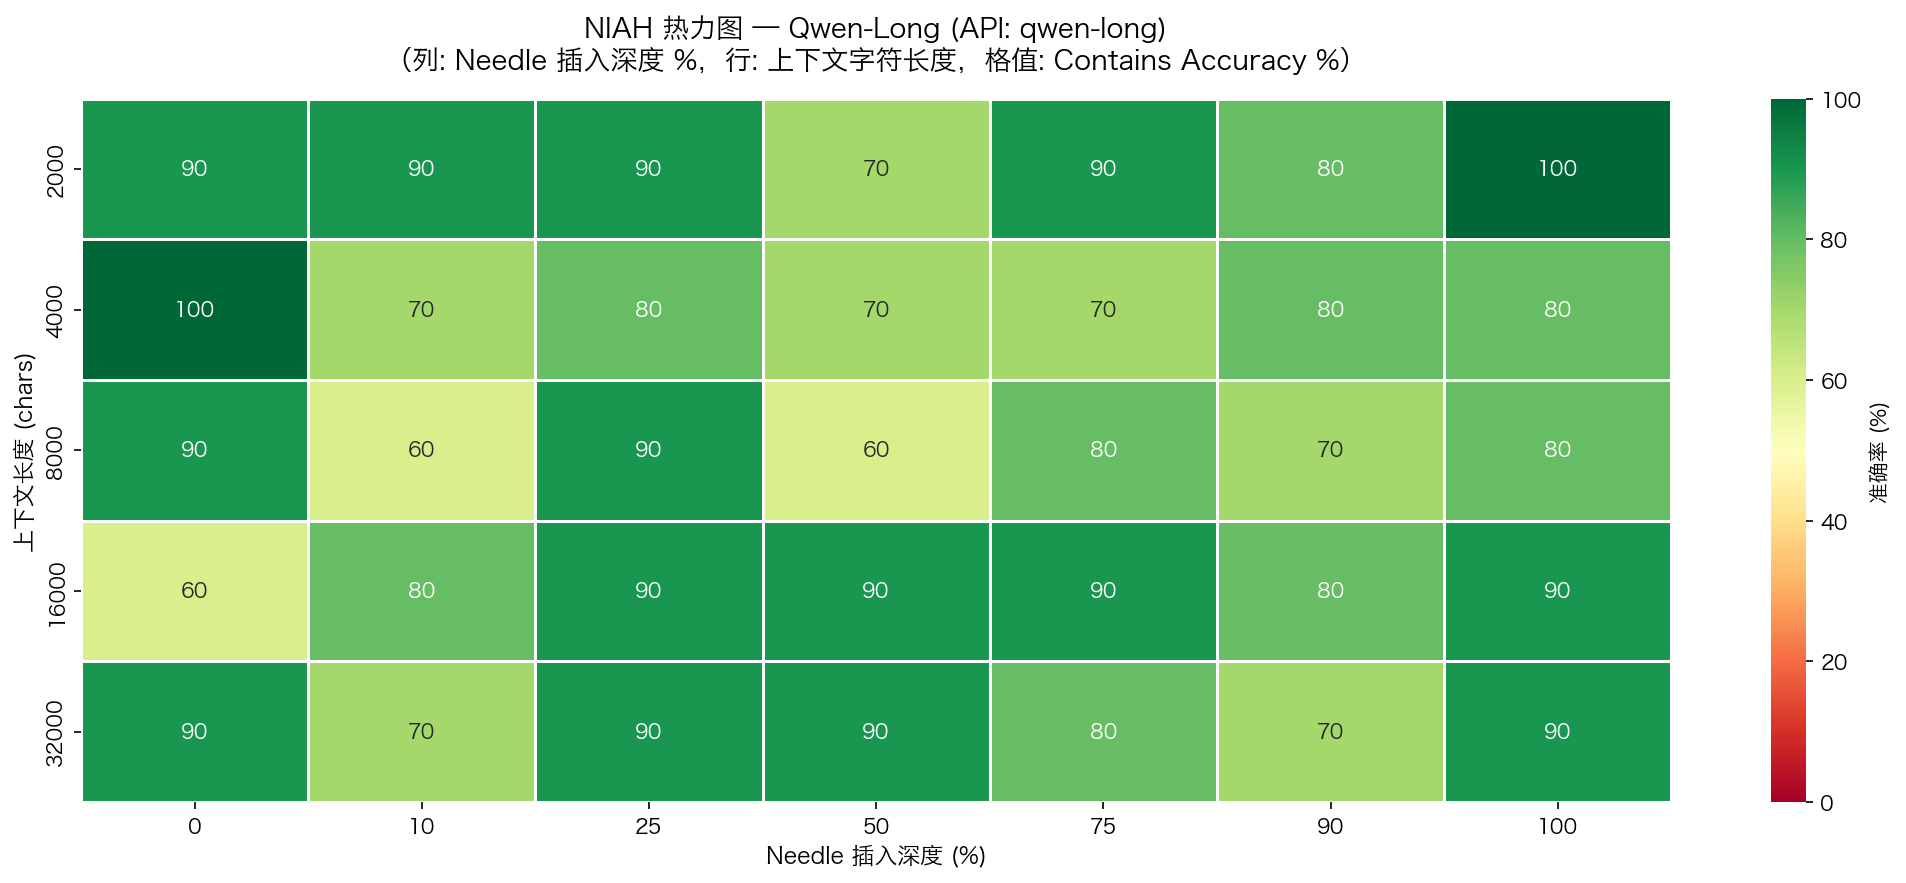

### 准确率 vs 上下文长度


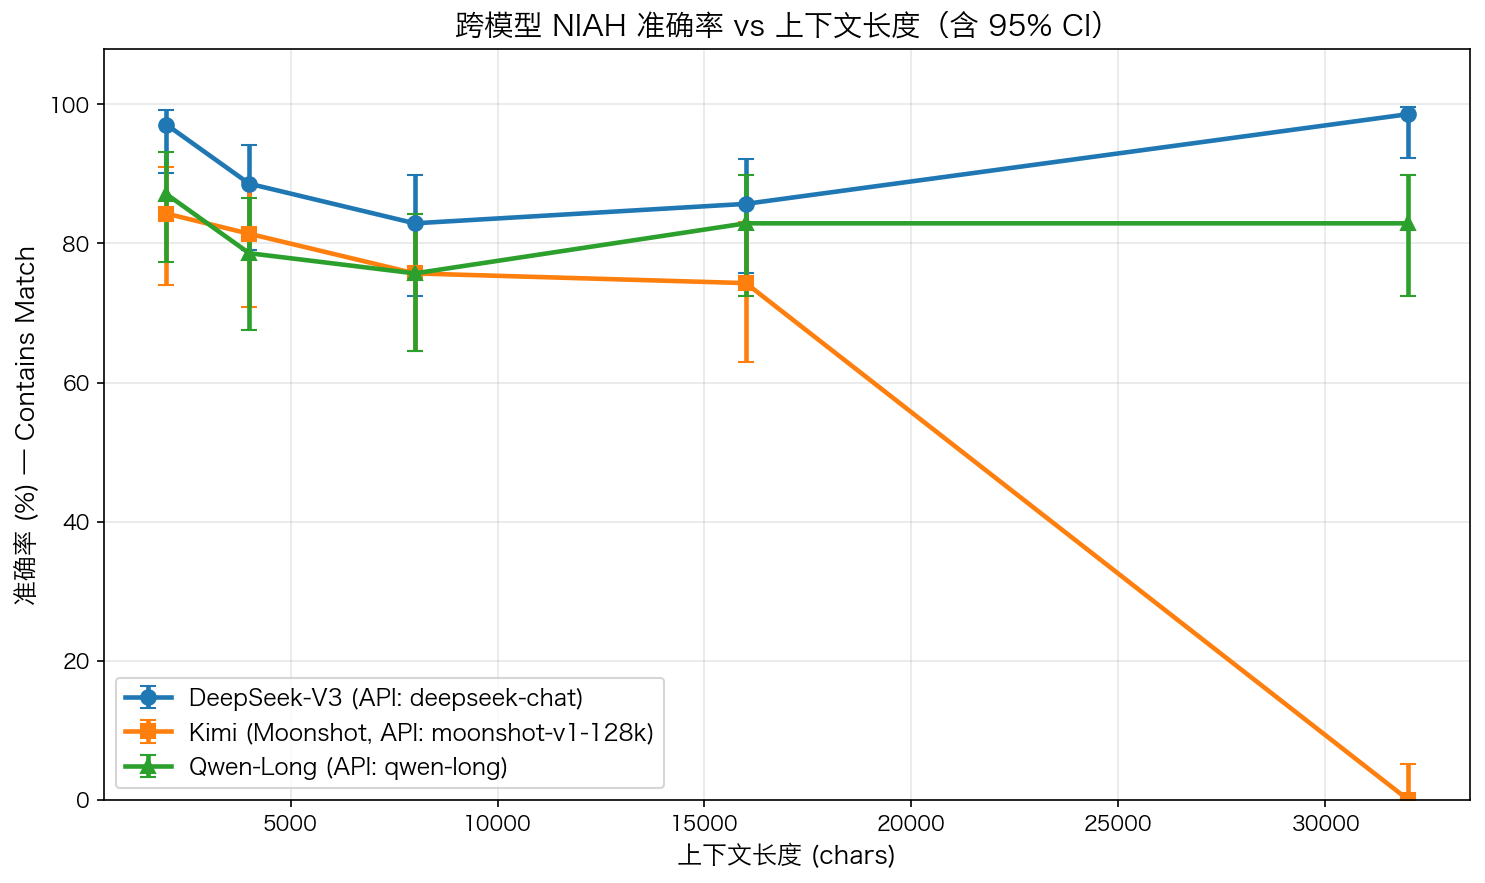

In [5]:
if scored_path.exists():
    for model in niah_df['model'].unique():
        img_path = figures_dir / f'niah_heatmap_{model}.png'
        if img_path.exists():
            print(f'### {format_model_name(model)}')
            ipy_display(Image(str(img_path)))
        else:
            print(f'图片未找到: {img_path}')

    accuracy_img = figures_dir / 'accuracy_by_length_with_ci.png'
    if accuracy_img.exists():
        print('### 准确率 vs 上下文长度')
        ipy_display(Image(str(accuracy_img)))

## 5. 效率与位置偏差图

### efficiency_tradeoff.png


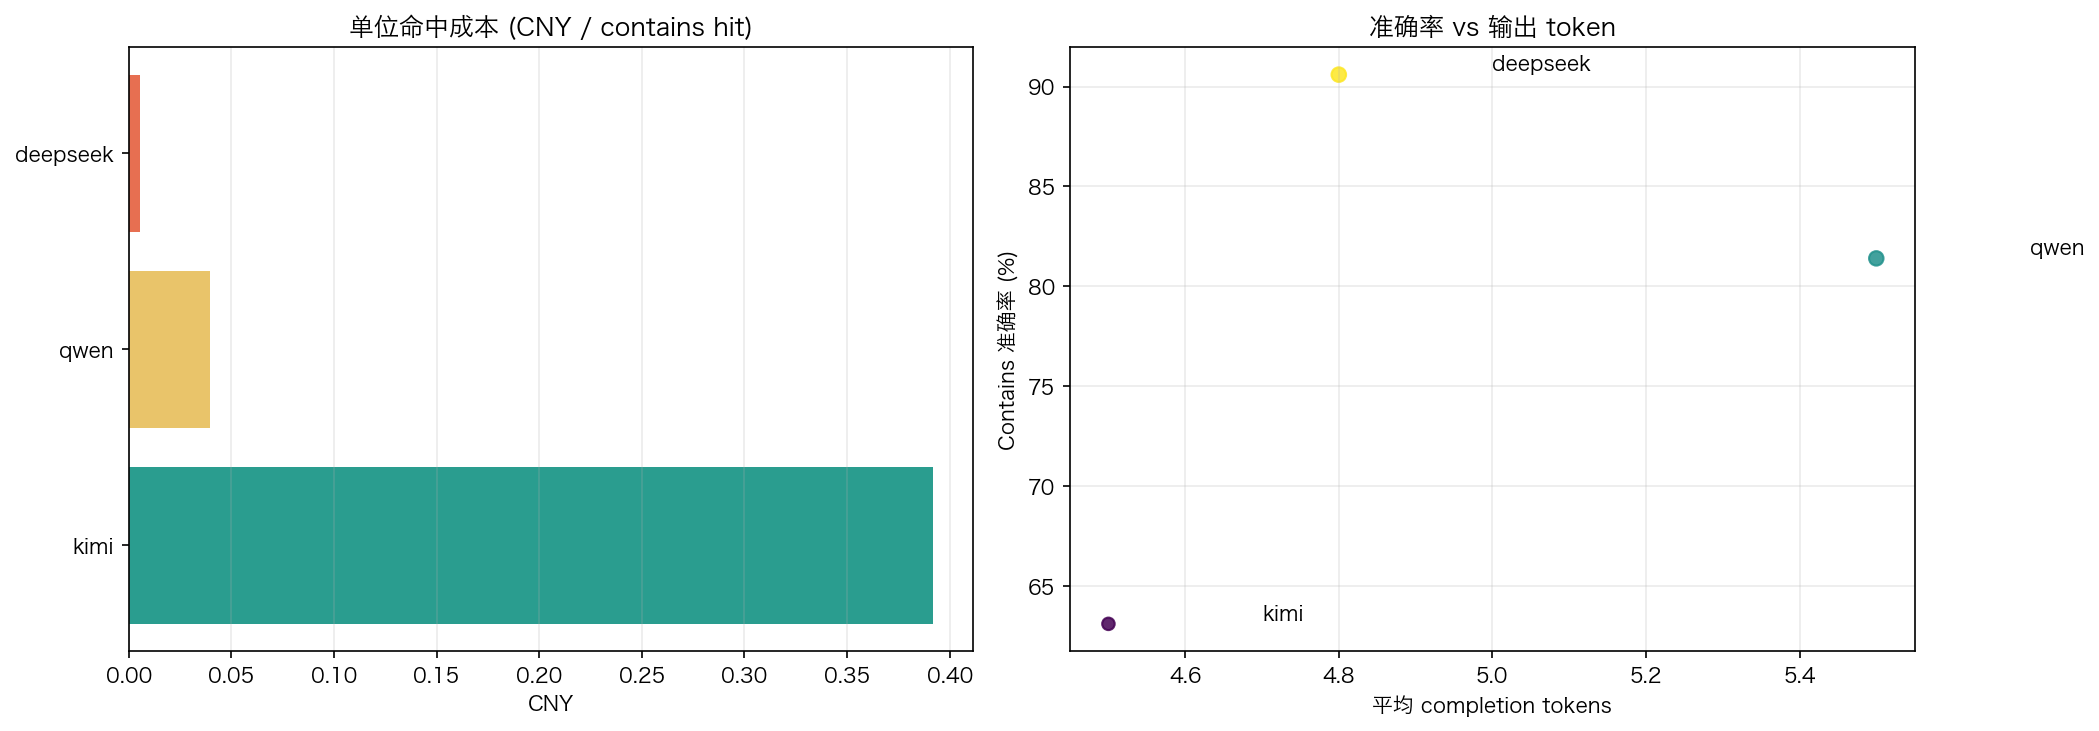

### position_bias.png


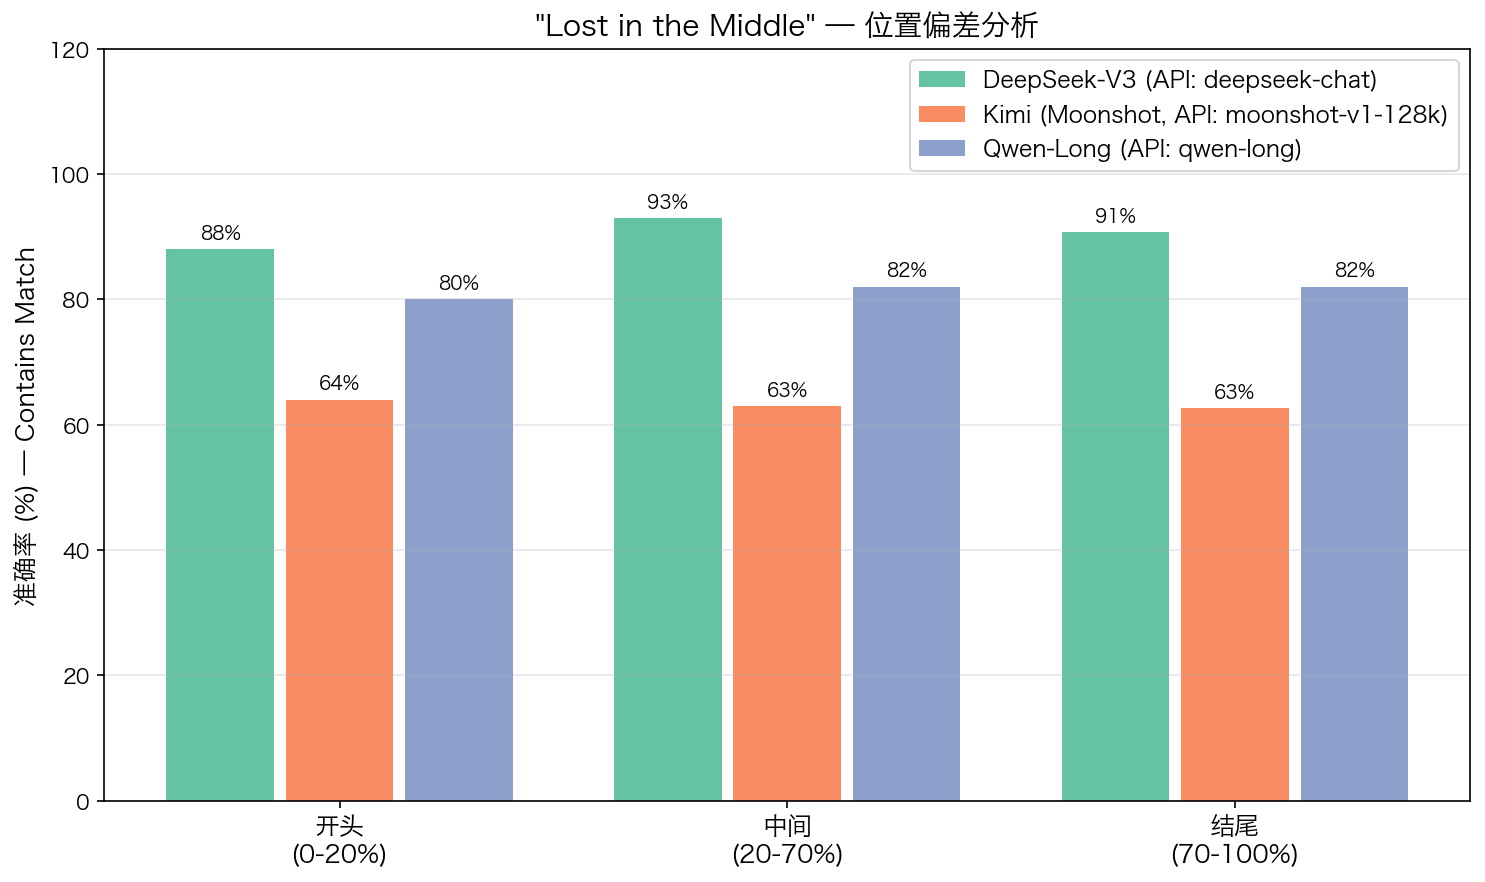

### depth_accuracy_curve.png


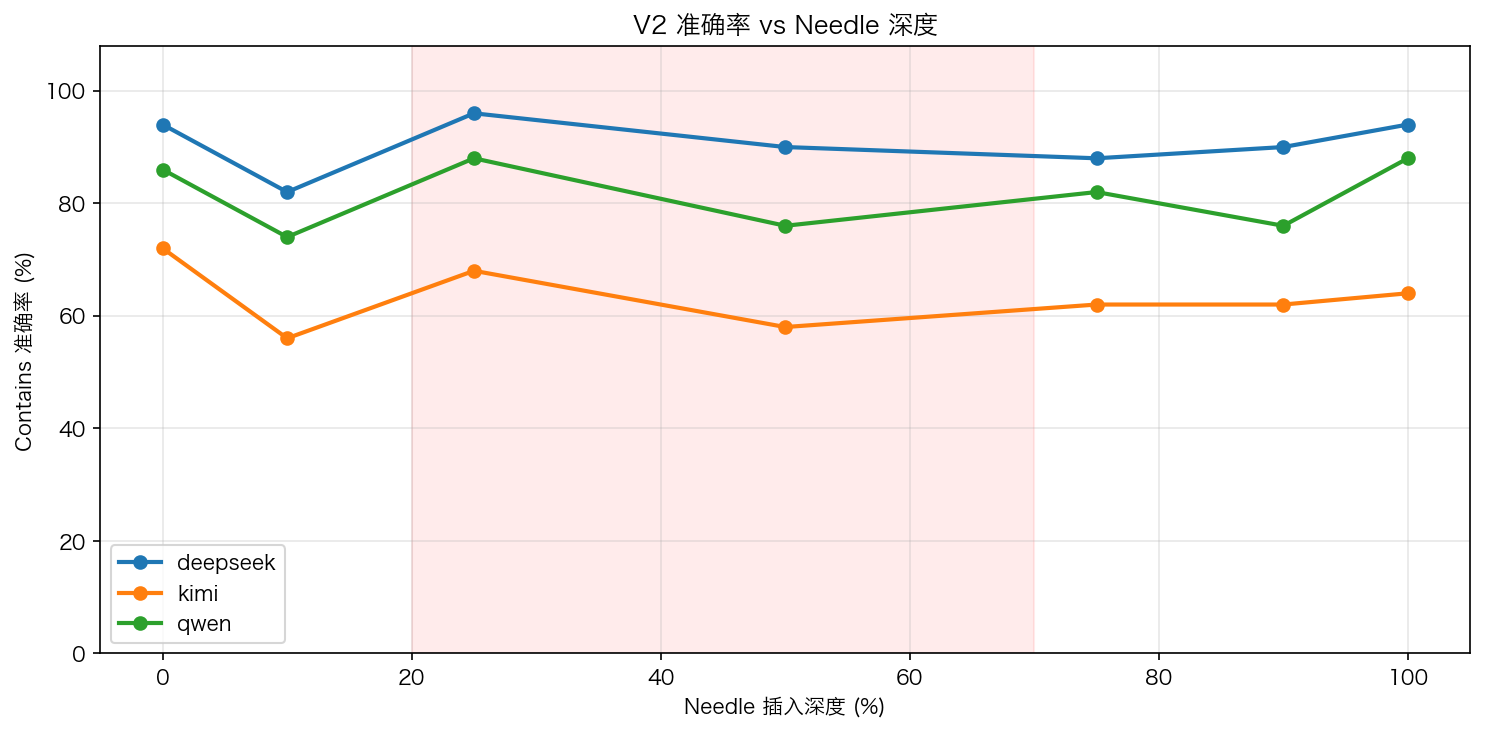

In [6]:
if scored_path.exists():
    for name in ['efficiency_tradeoff.png', 'position_bias.png', 'depth_accuracy_curve.png']:
        img_path = figures_dir / name
        if img_path.exists():
            print(f'### {name}')
            ipy_display(Image(str(img_path)))
        else:
            print(f'图片未找到: {img_path}')

## 6. Badcase Taxonomy

整体 badcase taxonomy（包含 Contains miss 与 EM-only miss）：


,badcase_taxonomy,n,share_pct
4,输出冗余但包含正确答案,123,35.1
3,被相似数字干扰,112,32.0
0,多 key 条件下定位失败,61,17.4
1,未作答或信息未命中,28,8.0
2,深层位置召回失败,26,7.4


按模型拆分：


badcase_taxonomy,被相似数字干扰,深层位置召回失败,输出冗余但包含正确答案,多 key 条件下定位失败,未作答或信息未命中
model,,,,,
DeepSeek-V3 (API: deepseek-chat),16,4,103,10,3
"Kimi (Moonshot, API: moonshot-v1-128k)",53,16,15,41,19
Qwen-Long (API: qwen-long),43,6,5,10,6


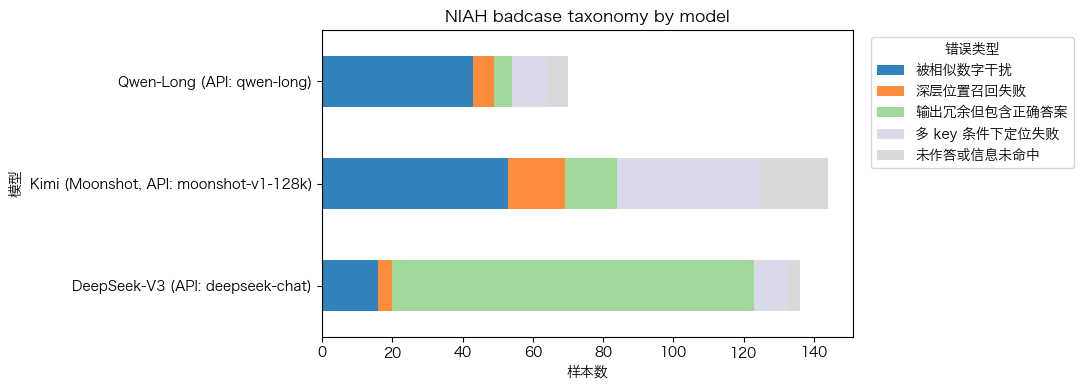

每类 1 条代表性失败样本：


,badcase_taxonomy,model,variant,question,expected_answer,model_response
80,多 key 条件下定位失败,DeepSeek-V3 (API: deepseek-chat),multi_key,A3 产线切换到新工艺的正式日期是哪天？,2025年6月18日,NaN
159,未作答或信息未命中,DeepSeek-V3 (API: deepseek-chat),style_aligned,公司 2025 年资本开支上限是多少？,18.6亿元,NaN
175,深层位置召回失败,DeepSeek-V3 (API: deepseek-chat),style_aligned,公司 2025 年资本开支上限是多少？,18.6亿元,NaN
11,被相似数字干扰,DeepSeek-V3 (API: deepseek-chat),numeric_confusable,区域配送的 SLA 指标是多少？,92.1%,24小时履约率。
9,输出冗余但包含正确答案,DeepSeek-V3 (API: deepseek-chat),multi_key,院务会最终批准的日间手术中心新增床位数是多少？,42张,42张。


EM miss 但 Contains hit 的典型样本：


,model,variant,question,expected_answer,model_response
9,DeepSeek-V3 (API: deepseek-chat),multi_key,院务会最终批准的日间手术中心新增床位数是多少？,42张,42张。
13,DeepSeek-V3 (API: deepseek-chat),style_aligned,公司 2025 年资本开支上限是多少？,18.6亿元,18.6亿元。
16,DeepSeek-V3 (API: deepseek-chat),style_aligned,急诊药房重点监控药品的库存周转天数是多少？,6.5天,6.5天。
19,DeepSeek-V3 (API: deepseek-chat),style_aligned,急诊药房重点监控药品的库存周转天数是多少？,6.5天,6.5天。
27,DeepSeek-V3 (API: deepseek-chat),numeric_confusable,区域配送的 SLA 指标是多少？,92.1%,92.1% 的 24 小时履约率。
32,DeepSeek-V3 (API: deepseek-chat),style_aligned,急诊药房重点监控药品的库存周转天数是多少？,6.5天,6.5天。
33,DeepSeek-V3 (API: deepseek-chat),numeric_confusable,区域配送的 SLA 指标是多少？,92.1%,92.1% 的 24 小时履约率。
35,DeepSeek-V3 (API: deepseek-chat),style_aligned,本季度封装段一次良率目标是多少？,98.2%,98.2%。


## 7. multi-hop 正式结果与真实任务口径 Pilot

任务级对比：


,model,task,n,em_pct,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_latency_s,avg_response_chars,avg_completion_tokens,total_cost_cny,cost_per_contains_hit_cny,cost_per_em_hit_cny,contains_per_1k_output_tokens
0,DeepSeek-V3 (API: deepseek-chat),multi_hop,4,50.0,50.0,15.0,85.0,0.66,5.2,3.2,0.0005,0.0002,0.0002,145.83
2,"Kimi (Moonshot, API: moonshot-v1-128k)",multi_hop,4,25.0,50.0,15.0,85.0,0.64,8.5,7.2,0.0312,0.0156,0.0312,62.50
4,Qwen-Long (API: qwen-long),multi_hop,4,50.0,50.0,15.0,85.0,0.51,5.0,4.8,0.0020,0.0010,0.0010,100.00
1,DeepSeek-V3 (API: deepseek-chat),niah,350,61.1,90.6,87.1,93.2,0.73,6.1,4.8,1.8211,0.0057,0.0085,213.38
5,Qwen-Long (API: qwen-long),niah,350,80.0,81.4,77.0,85.2,7.14,6.0,5.5,11.3116,0.0397,0.0404,164.01
3,"Kimi (Moonshot, API: moonshot-v1-128k)",niah,350,58.9,63.1,58.0,68.0,1.06,4.5,4.5,86.6157,0.3919,0.4205,103.73


task,multi_hop,niah
model,,
DeepSeek-V3 (API: deepseek-chat),50.0,90.6
"Kimi (Moonshot, API: moonshot-v1-128k)",50.0,63.1
Qwen-Long (API: qwen-long),50.0,81.4


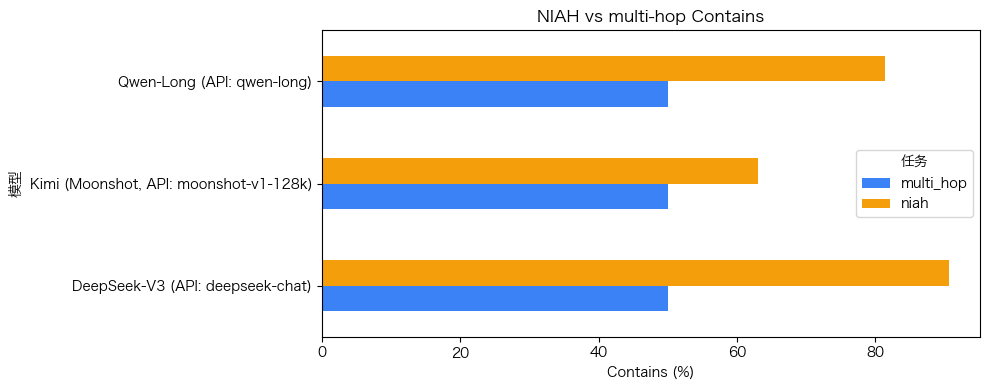

multi_hop 汇总：


,model,n,em_pct,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_latency_s,avg_response_chars,avg_completion_tokens,total_cost_cny,cost_per_contains_hit_cny,cost_per_em_hit_cny,contains_per_1k_output_tokens
0,DeepSeek-V3 (API: deepseek-chat),4,50.0,50.0,15.0,85.0,0.66,5.2,3.2,0.0005,0.0002,0.0002,145.83
1,"Kimi (Moonshot, API: moonshot-v1-128k)",4,25.0,50.0,15.0,85.0,0.64,8.5,7.2,0.0312,0.0156,0.0312,62.50
2,Qwen-Long (API: qwen-long),4,50.0,50.0,15.0,85.0,0.51,5.0,4.8,0.0020,0.0010,0.0010,100.00


按领域拆分：


,model,domain,n,em_pct,contains_pct,contains_ci_low_pct,contains_ci_high_pct
0,DeepSeek-V3 (API: deepseek-chat),finance,1,100.0,100.0,20.7,100.0
4,"Kimi (Moonshot, API: moonshot-v1-128k)",finance,1,100.0,100.0,20.7,100.0
8,Qwen-Long (API: qwen-long),finance,1,100.0,100.0,20.7,100.0
1,DeepSeek-V3 (API: deepseek-chat),healthcare,1,0.0,0.0,0.0,79.3
5,"Kimi (Moonshot, API: moonshot-v1-128k)",healthcare,1,0.0,0.0,0.0,79.3
9,Qwen-Long (API: qwen-long),healthcare,1,0.0,0.0,0.0,79.3
2,DeepSeek-V3 (API: deepseek-chat),manufacturing,1,100.0,100.0,20.7,100.0
6,"Kimi (Moonshot, API: moonshot-v1-128k)",manufacturing,1,0.0,100.0,20.7,100.0
10,Qwen-Long (API: qwen-long),manufacturing,1,100.0,100.0,20.7,100.0
3,DeepSeek-V3 (API: deepseek-chat),retail,1,0.0,0.0,0.0,79.3


multi_hop badcase taxonomy：


...

,sample_id,domain,difficulty,hops,context_length,question,expected_answer
0,v2-multihop-001,finance,medium,2,56,按照计划，2025 年第一季度对应的研发费用预算约是多少？,9.45亿元
1,v2-multihop-002,manufacturing,medium,2,47,按标准产能估算，A5 产线一天可生产多少件？,2520件
2,v2-multihop-003,healthcare,hard,2,60,按质控要求，夜班样本最晚应在什么时间前回传结果？,23:30前
3,v2-multihop-004,retail,hard,2,41,按样板计划估算，本月应有多少名新会员在首月完成复购？,1536人


真实任务子集扩充路线：


,subset,target_samples,design_goal
0,长文档关键信息抽取,12,验证模型在长文档里定位并抽取关键数值/时间/实体的能力
1,中文财报 / 研报问答,10,验证模型能否在多指标并列时锁定目标财务口径
2,多段政策文本比对,8,验证跨段落条件对齐、例外条款识别和版本差异判断
3,客服知识库长上下文检索问答,10,验证真实 FAQ / SOP 语料里的检索定位与简洁作答


## 8. 优化建议与数据策略

1. numeric_confusable 当前平均 Contains 最低 (67.3%)，说明模型对相似数字 / 相邻口径区分仍弱，下一轮应补更多相似数值干扰样本，并把数字单位、时间、百分比混排进同一段上下文。
2. Kimi 在 32K 下出现近似崩塌，Contains=0.0%，95% CI=[0.0, 5.2]，优先排查长上下文 prompt 模板、截断策略、以及模型是否稳定输出空响应。
3. DeepSeek 的 Contains 明显高于 EM，gap=29.5pp，说明定位能力已经足够，但抽取格式仍不够稳定；下一轮应补格式约束、短答案 extraction-style prompt，以及更多“只返回目标值”的训练样本。
4. multi-hop 已正式进入统一报告，但当前每模型只有 4 条样本，Contains 全部停在 50.0%%。下一步应把 real-task slice 扩到 30-50 条，并把中间推理链、单位换算、时间约束等失败模式单独标注。
5. 当前最常见的 badcase 类型是“输出冗余但包含正确答案”（35.1%）。这意味着后续优化不能只盯整体准确率，还需要把该类样本单独做回归集。


In [7]:
from IPython.display import Markdown, display

if scored_path.exists():
    display(Markdown('## 6. Badcase Taxonomy'))
    if not niah_badcase_summary_overall.empty:
        print('整体 badcase taxonomy（包含 Contains miss 与 EM-only miss）：')
        overall_taxonomy_display = niah_badcase_summary_overall.sort_values('n', ascending=False)[['badcase_taxonomy', 'n', 'share_pct']]
        display(overall_taxonomy_display)

        taxonomy_pivot = (
            with_model_labels(niah_badcase_summary[['model', 'badcase_taxonomy', 'n']])
            .pivot(index='model', columns='badcase_taxonomy', values='n')
            .fillna(0)
            .astype(int)
        )
        ordered_cols = [col for col in BADCASE_DISPLAY_ORDER if col in taxonomy_pivot.columns]
        ordered_cols += [col for col in taxonomy_pivot.columns if col not in ordered_cols]
        taxonomy_pivot = taxonomy_pivot[ordered_cols]

        print('按模型拆分：')
        display(taxonomy_pivot)

        if not taxonomy_pivot.empty:
            ax = taxonomy_pivot.plot(kind='barh', stacked=True, figsize=(11, 4), colormap='tab20c')
            ax.set_title('NIAH badcase taxonomy by model')
            ax.set_xlabel('样本数')
            ax.set_ylabel('模型')
            ax.legend(title='错误类型', bbox_to_anchor=(1.02, 1), loc='upper left')
            plt.tight_layout()
            plt.show()

    if not representative_badcases.empty:
        print('每类 1 条代表性失败样本：')
        report_badcase_examples = (
            representative_badcases.groupby('badcase_taxonomy', dropna=False)
            .head(1)[['badcase_taxonomy', 'model', 'variant', 'question', 'expected_answer', 'model_response']]
        )
        display(with_model_labels(report_badcase_examples))

    if not em_gap_examples.empty:
        print('EM miss 但 Contains hit 的典型样本：')
        display(with_model_labels(em_gap_examples[['model', 'variant', 'question', 'expected_answer', 'model_response']].head(8)))

    display(Markdown('## 7. multi-hop 正式结果与真实任务口径 Pilot'))
    if not task_summary.empty:
        print('任务级对比：')
        task_display = with_model_labels(task_summary).sort_values(['task', 'contains_pct'], ascending=[True, False])
        display(task_display)

        task_pivot = (
            with_model_labels(task_summary[['model', 'task', 'contains_pct']])
            .pivot(index='model', columns='task', values='contains_pct')
            .round(1)
        )
        display(task_pivot)

        if not task_pivot.empty:
            ax = task_pivot.plot(kind='barh', figsize=(10, 4), color=['#3b82f6', '#f59e0b'])
            ax.set_title('NIAH vs multi-hop Contains')
            ax.set_xlabel('Contains (%)')
            ax.set_ylabel('模型')
            ax.legend(title='任务')
            plt.tight_layout()
            plt.show()

    if not multihop_summary.empty:
        print('multi_hop 汇总：')
        display(with_model_labels(multihop_summary))

        if not multihop_domain_summary.empty:
            print('按领域拆分：')
            display(
                with_model_labels(
                    multihop_domain_summary[
                        ['model', 'domain', 'n', 'em_pct', 'contains_pct', 'contains_ci_low_pct', 'contains_ci_high_pct']
                    ].sort_values(['domain', 'contains_pct'], ascending=[True, False])
                )
            )

        if not multihop_badcase_summary.empty:
            print('multi_hop badcase taxonomy：')
            display(with_model_labels(multihop_badcase_summary))

        print('multi_hop 逐条结果：')
        display(
            with_model_labels(
                multihop_df[
                    ['model', 'domain', 'difficulty', 'question', 'expected_answer', 'model_response', 'contains_score', 'badcase_taxonomy']
                ].sort_values(['model', 'domain'])
            )
        )
        print('当前 multi_hop 只有 4 条人工设计的真实业务口径样本 / 模型，95% CI 仍然很宽，应把它视为已经正式纳入统一报告的 pilot slice，而不是最终排名。')

    if not real_task_pilot_df.empty:
        print('当前真实任务口径 pilot 样本：')
        display(real_task_pilot_df)

    real_task_roadmap = pd.DataFrame(
        [
            {
                'subset': '长文档关键信息抽取',
                'target_samples': 12,
                'design_goal': '验证模型在长文档里定位并抽取关键数值/时间/实体的能力',
            },
            {
                'subset': '中文财报 / 研报问答',
                'target_samples': 10,
                'design_goal': '验证模型能否在多指标并列时锁定目标财务口径',
            },
            {
                'subset': '多段政策文本比对',
                'target_samples': 8,
                'design_goal': '验证跨段落条件对齐、例外条款识别和版本差异判断',
            },
            {
                'subset': '客服知识库长上下文检索问答',
                'target_samples': 10,
                'design_goal': '验证真实 FAQ / SOP 语料里的检索定位与简洁作答',
            },
        ]
    )
    real_task_roadmap.to_csv(processed_dir / 'real_task_subset_roadmap.csv', index=False, encoding='utf-8-sig')
    print('真实任务子集扩充路线：')
    display(real_task_roadmap)

    display(Markdown('## 8. 优化建议与数据策略'))
    recommendations = []

    if not variant_summary.empty:
        variant_order = variant_summary.groupby('variant')['contains_pct'].mean().sort_values()
        hardest_variant = variant_order.index[0]
        hardest_variant_score = variant_order.iloc[0]
        recommendations.append(
            f'{hardest_variant} 当前平均 Contains 最低 ({hardest_variant_score:.1f}%)，说明模型对相似数字 / 相邻口径区分仍弱，下一轮应补更多相似数值干扰样本，并把数字单位、时间、百分比混排进同一段上下文。'
        )

    if not length_summary.empty:
        kimi_32k = length_summary[(length_summary['model'] == 'kimi') & (length_summary['context_length'] == 32000)]
        if not kimi_32k.empty:
            kimi_row = kimi_32k.iloc[0]
            recommendations.append(
                'Kimi 在 32K 下出现近似崩塌，Contains=%.1f%%，95%% CI=[%.1f, %.1f]，优先排查长上下文 prompt 模板、截断策略、以及模型是否稳定输出空响应。'
                % (kimi_row['contains_pct'], kimi_row['contains_ci_low_pct'], kimi_row['contains_ci_high_pct'])
            )

    if not model_summary.empty:
        deepseek_row = model_summary[model_summary['model'] == 'deepseek']
        if not deepseek_row.empty:
            deepseek_gap = deepseek_row.iloc[0]['contains_pct'] - deepseek_row.iloc[0]['em_pct']
            recommendations.append(
                'DeepSeek 的 Contains 明显高于 EM，gap=%.1fpp，说明定位能力已经足够，但抽取格式仍不够稳定；下一轮应补格式约束、短答案 extraction-style prompt，以及更多“只返回目标值”的训练样本。'
                % deepseek_gap
            )

    if not multihop_summary.empty:
        recommendations.append(
            'multi-hop 已正式进入统一报告，但当前每模型只有 4 条样本，Contains 全部停在 50.0%%。下一步应把 real-task slice 扩到 30-50 条，并把中间推理链、单位换算、时间约束等失败模式单独标注。'
        )

    if not niah_badcase_summary_overall.empty:
        top_badcase = niah_badcase_summary_overall.sort_values('n', ascending=False).iloc[0]
        recommendations.append(
            '当前最常见的 badcase 类型是“%s”（%.1f%%）。这意味着后续优化不能只盯整体准确率，还需要把该类样本单独做回归集。'
            % (top_badcase['badcase_taxonomy'], top_badcase['share_pct'])
        )

    for idx, recommendation in enumerate(recommendations, start=1):
        print(f'{idx}. {recommendation}')

## 9. 写作提纲

### 9.1 NIAH 主结论
- 先给 NIAH 总体强弱：谁的 Contains 最高，谁的 EM 更稳，谁的单位命中成本最低。
- 对 DeepSeek 要明确区分“定位能力强”和“输出格式不够收敛”，不要只写成泛化的准确率优势。
- 对 Kimi 32K 的结论要保留 Wilson 区间，不要把稳定失效信号弱化成一次随机波动。

### 9.2 Badcase Taxonomy
- 单独写 taxonomy 排名，至少点出“输出冗余但包含正确答案”“被相似数字干扰”“多 key 条件下定位失败”三类主导错误。
- 每类错误给 1 条代表性样本，形成“统计 + 例子”的桥接。
- 把 taxonomy 明确转成优化动作，而不是停在失败描述上。

### 9.3 multi-hop 与真实任务口径 Pilot
- 说明 multi_hop 已正式并入统一报告，但当前只有 4 条样本 / 模型，统计上仍属于 pilot。
- 重点写“所有模型 Contains 都是 50.0%，但区间仍宽”，防止过度解读当前排序。
- 把 multi_hop 明确定位为 real-task slice 的第一批正式结果，为后续 30-50 条扩充铺路。

### 9.4 优化建议与数据策略
- `numeric_confusable` 最难，建议扩充相似数字、单位、时间、百分比混排样本。
- 32K 某模型崩塌，建议排查 prompt 模板、截断逻辑、空响应比例和长上下文策略。
- DeepSeek Contains 高但 EM gap 大，建议补“只返回目标值”的 extraction-style 约束和训练样本。

### 9.5 下一轮动作
1. 把 real-task pilot 从 4 条扩到 30-50 条，并覆盖长文档抽取、财报问答、政策比对、知识库检索四类场景。
2. 为 badcase taxonomy 建专门回归集，至少保证相似数字干扰、多 key 定位、冗余输出三类都可单独回放。
3. 在导出对外版报告前，把 README、报告 HTML、执行版 notebook 保持同一份结论口径。

In [8]:
if scored_path.exists() and not model_summary.empty:
    print('自动摘要草稿：')

    best_contains = model_summary.sort_values(['contains_pct', 'contains_ci_low_pct'], ascending=False).iloc[0]
    cheapest = model_summary.sort_values('cost_per_contains_hit_cny', ascending=True).iloc[0]
    most_verbose = model_summary.sort_values('avg_completion_tokens', ascending=False).iloc[0]

    print(
        f'1. 当前 NIAH Contains 最强模型是 {format_model_name(best_contains["model"])}，'
        f'准确率 {best_contains["contains_pct"]:.1f}%，'
        f'95% CI 下界 {best_contains["contains_ci_low_pct"]:.1f}%。'
    )
    print(
        f'2. 当前单位命中成本最低的是 {format_model_name(cheapest["model"])}，'
        f'{cheapest["cost_per_contains_hit_cny"]:.4f} CNY / contains hit。'
    )
    print(
        f'3. 当前输出最啰嗦的是 {format_model_name(most_verbose["model"])}，'
        f'平均 completion {most_verbose["avg_completion_tokens"]:.1f} tokens。'
    )

    if not niah_badcase_summary_overall.empty:
        top_badcase = niah_badcase_summary_overall.sort_values('n', ascending=False).iloc[0]
        print(
            f'4. 当前最常见的 badcase 类型是“{top_badcase["badcase_taxonomy"]}”，'
            f'占全部 badcase 的 {top_badcase["share_pct"]:.1f}%。'
        )

    if not variant_summary.empty:
        variant_order = variant_summary.groupby('variant')['contains_pct'].mean().sort_values()
        hardest_variant = variant_order.index[0]
        easiest_variant = variant_order.index[-1]
        hardest_variant_score = variant_order.iloc[0]
        easiest_variant_score = variant_order.iloc[-1]
        print(
            f'5. 平均来看最难的变体是 {hardest_variant} ({hardest_variant_score:.1f}%)，'
            f'最容易的变体是 {easiest_variant} ({easiest_variant_score:.1f}%)。'
        )
        if hardest_variant == 'numeric_confusable':
            print('   这说明相近数字 / 字符串干扰比 style 对齐或多 key 干扰更容易击穿检索稳定性。')

    stability_focus = length_summary[length_summary['context_length'].isin([16000, 32000])].copy()
    if not stability_focus.empty:
        print('6. 16K / 32K 观察：')
        for context_length in [16000, 32000]:
            sub = stability_focus[stability_focus['context_length'] == context_length]
            if sub.empty:
                continue
            best_row = sub.sort_values('contains_pct', ascending=False).iloc[0]
            worst_row = sub.sort_values('contains_pct', ascending=True).iloc[0]
            gap = best_row['contains_pct'] - worst_row['contains_pct']
            print(
                f'   {context_length} chars: 最强 {format_model_name(best_row["model"])}={best_row["contains_pct"]:.1f}%,'
                f' 最弱 {format_model_name(worst_row["model"])}={worst_row["contains_pct"]:.1f}%, 差值 {gap:.1f}pp'
            )

        kimi_32k = stability_focus[
            (stability_focus['model'] == 'kimi')
            & (stability_focus['context_length'] == 32000)
        ]
        if not kimi_32k.empty:
            kimi_row = kimi_32k.iloc[0]
            print(
                f'   技术备注: {format_model_name("kimi")} 在 32000 chars 下 Contains={kimi_row["contains_pct"]:.1f}%，'
                f'95% CI=[{kimi_row["contains_ci_low_pct"]:.1f}, {kimi_row["contains_ci_high_pct"]:.1f}]。'
            )
            print('   这个区间上界仍然很低，更接近稳定失效，而不是一次偶然波动。')

    if not multihop_summary.empty:
        print('7. multi_hop 已正式进入统一报告。')
        print(
            '   当前 3 个模型在 pilot 上的 Contains 都是 50.0%，但每模型只有 4 条样本，'
            '95% CI 仍然是 [15.0, 85.0]，因此更适合作为 real-task slice 的起点，而不是最终排序依据。'
        )
        display(with_model_labels(multihop_summary))
    else:
        print('7. multi_hop 结果尚未进入 scored_results.csv。')

    if not real_task_pilot_df.empty:
        print(
            f'8. 当前 real-task pilot 已覆盖 {len(real_task_pilot_df)} 条样本，涉及 '
            f'{real_task_pilot_df["domain"].nunique()} 个领域。下一步可按 roadmap 扩到 30-50 条。'
        )

自动摘要草稿：
1. 当前 NIAH Contains 最强模型是 DeepSeek-V3 (API: deepseek-chat)，准确率 90.6%，95% CI 下界 87.1%。
2. 当前单位命中成本最低的是 DeepSeek-V3 (API: deepseek-chat)，0.0057 CNY / contains hit。
3. 当前输出最啰嗦的是 Qwen-Long (API: qwen-long)，平均 completion 5.5 tokens。
4. 当前最常见的 badcase 类型是“输出冗余但包含正确答案”，占全部 badcase 的 35.1%。
5. 平均来看最难的变体是 numeric_confusable (67.3%)，最容易的变体是 style_aligned (84.5%)。
   这说明相近数字 / 字符串干扰比 style 对齐或多 key 干扰更容易击穿检索稳定性。
6. 16K / 32K 观察：
   16000 chars: 最强 DeepSeek-V3 (API: deepseek-chat)=85.7%, 最弱 Kimi (Moonshot, API: moonshot-v1-128k)=74.3%, 差值 11.4pp
   32000 chars: 最强 DeepSeek-V3 (API: deepseek-chat)=98.6%, 最弱 Kimi (Moonshot, API: moonshot-v1-128k)=0.0%, 差值 98.6pp
   技术备注: Kimi (Moonshot, API: moonshot-v1-128k) 在 32000 chars 下 Contains=0.0%，95% CI=[0.0, 5.2]。
   这个区间上界仍然很低，更接近稳定失效，而不是一次偶然波动。
7. multi_hop 已正式进入统一报告。
   当前 3 个模型在 pilot 上的 Contains 都是 50.0%，但每模型只有 4 条样本，95% CI 仍然是 [15.0, 85.0]，因此更适合作为 real-task slice 的起点，而不是最终排序依据。


,model,n,em_pct,contains_pct,contains_ci_low_pct,contains_ci_high_pct,avg_latency_s,avg_response_chars,avg_completion_tokens,total_cost_cny,cost_per_contains_hit_cny,cost_per_em_hit_cny,contains_per_1k_output_tokens
0,DeepSeek-V3 (API: deepseek-chat),4,50.0,50.0,15.0,85.0,0.66,5.2,3.2,0.0005,0.0002,0.0002,145.83
1,"Kimi (Moonshot, API: moonshot-v1-128k)",4,25.0,50.0,15.0,85.0,0.64,8.5,7.2,0.0312,0.0156,0.0312,62.50
2,Qwen-Long (API: qwen-long),4,50.0,50.0,15.0,85.0,0.51,5.0,4.8,0.0020,0.0010,0.0010,100.00


8. 当前 real-task pilot 已覆盖 4 条样本，涉及 4 个领域。下一步可按 roadmap 扩到 30-50 条。
